## Pokemon Data Analysis

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pokemon_df = pd.read_csv('pokemon_data.csv')



WE check the shape of the dataset to understand how many rows and columns it contains. This will help us get an overview of the data we are working with.

In [27]:
print(Pokemon_df.shape)
print(Pokemon_df.isna().sum())
print(Pokemon_df.dtypes)


(800, 12)
#               0
Name            0
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64
#             int64
Name            str
Type 1          str
Type 2          str
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object


We can see that the dataset contains 800 rows and 13 columns. This means we have information on 800 different Pokémon, and each Pokémon has 13 attributes or features that describe it.

Next, we want to visualize the type1 column to see the distribution of Pokémon types. This will help us understand which types are more common in our dataset.

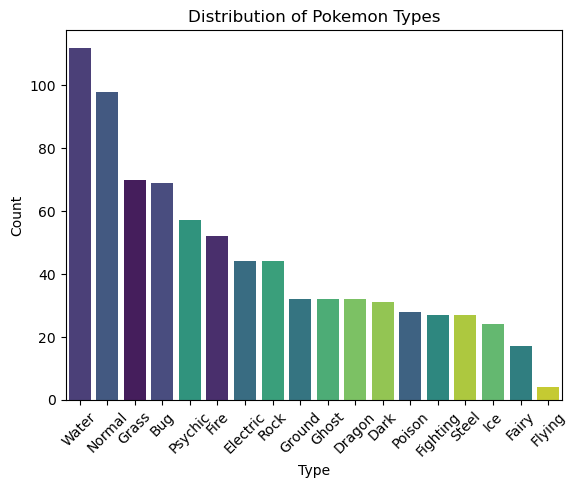

In [28]:
plt.Figure(figsize=(12,5))
order = Pokemon_df['Type 1'].value_counts().index
sns.countplot(data=Pokemon_df, x='Type 1',order=order,hue='Type 1' ,palette='viridis')
plt.title('Distribution of Pokemon Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


We can see That water Type is the most common type among the Pokémon in our dataset, followed by Normal and Grass types. This information can be useful for further analysis, such as understanding the strengths and weaknesses of different Pokémon types or identifying trends in Pokémon characteristics.

next, we want to find out the attack distribution of the Pokémon in our dataset. We can do this by creating a histogram of the Attack column. This will help us understand how the attack values are distributed among the Pokémon and identify any patterns or outliers in the data.

In [29]:
Pokemon_df['Attack'].describe()

count    800.000000
mean      79.001250
std       32.457366
min        5.000000
25%       55.000000
50%       75.000000
75%      100.000000
max      190.000000
Name: Attack, dtype: float64

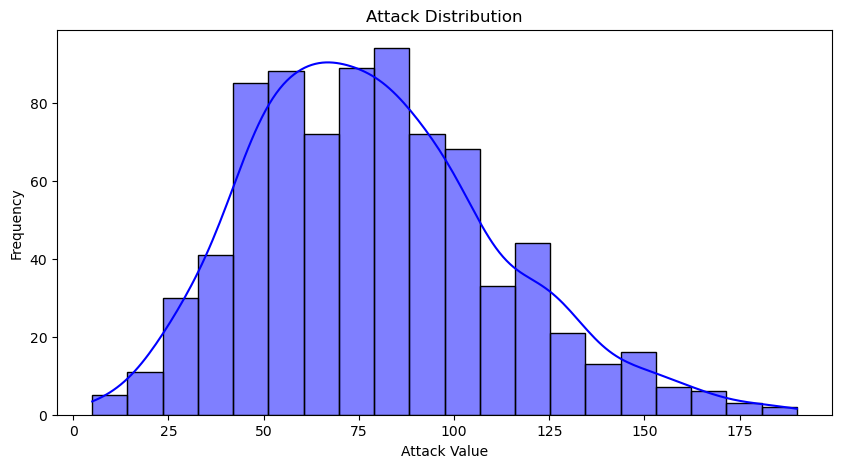

In [30]:
plt.figure(figsize=(10,5))
Attack_order= Pokemon_df['Attack'].value_counts().index
sns.histplot(data=Pokemon_df, x='Attack', bins=20, kde=True, color='blue')
plt.xlabel('Attack Value')
plt.ylabel('Frequency')
plt.title('Attack Distribution')
plt.show()

we can see that the attack values are distributed in a way that most Pokémon have attack values between 75 and 100, with a few outliers having very high attack values above 170. This information can be useful for identifying powerful Pokémon and understanding the overall distribution of attack strengths in our dataset.

Next, we want to find out which Pokémon have the highest attack values. We can do this by filtering the dataset to include only those Pokémon with attack values greater than 170. This will help us identify the most powerful Pokémon in terms of attack strength.

In [31]:
highest_atk=Pokemon_df[Pokemon_df['Attack']>170]
print(highest_atk[['Name','Attack']])


                        Name  Attack
163      MewtwoMega Mewtwo X     190
232  HeracrossMega Heracross     185
424    GroudonPrimal Groudon     180
426    RayquazaMega Rayquaza     180
429       DeoxysAttack Forme     180


In [32]:
Pokemon_df['Total_Stats']=Pokemon_df[['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed']].sum(axis=1)
Pokemon_df['Offence_Index']=Pokemon_df['Attack']+Pokemon_df['Sp. Atk']
Pokemon_df['Bulk_Index']=Pokemon_df['HP']+Pokemon_df['Sp. Def']+Pokemon_df['Defense']
Pokemon_df['Defence_Index']=Pokemon_df['Sp. Def']+Pokemon_df['Defense']

In [33]:
pokemon_highest_stats=Pokemon_df.sort_values('Total_Stats',ascending=False)
print(pokemon_highest_stats.head(20))

       #                     Name   Type 1    Type 2   HP  Attack  Defense  \
426  384    RayquazaMega Rayquaza   Dragon    Flying  105     180      100   
164  150      MewtwoMega Mewtwo Y  Psychic       NaN  106     150       70   
163  150      MewtwoMega Mewtwo X  Psychic  Fighting  106     190      100   
422  382      KyogrePrimal Kyogre    Water       NaN  100     150       90   
424  383    GroudonPrimal Groudon   Ground      Fire  100     180      160   
552  493                   Arceus   Normal       NaN  120     120      120   
712  646       KyuremWhite Kyurem   Dragon       Ice  125     120       90   
711  646       KyuremBlack Kyurem   Dragon       Ice  125     170      100   
409  373  SalamenceMega Salamence   Dragon    Flying   95     145      130   
413  376  MetagrossMega Metagross    Steel   Psychic   80     145      150   
418  380        LatiasMega Latias   Dragon   Psychic   80     100      120   
420  381        LatiosMega Latios   Dragon   Psychic   80     13

In [34]:
type_strength=(Pokemon_df.groupby('Type 1'))['Total_Stats'].agg(['mean','median','count']).sort_values('mean',ascending=False)
print(type_strength)

                mean  median  count
Type 1                             
Dragon    550.531250   600.0     32
Steel     487.703704   500.0     27
Flying    485.000000   557.5      4
Psychic   475.947368   485.0     57
Fire      458.076923   482.0     52
Rock      453.750000   467.5     44
Dark      445.741935   465.0     31
Electric  443.409091   477.5     44
Ghost     439.562500   464.5     32
Ground    437.500000   440.0     32
Ice       433.458333   467.5     24
Water     430.455357   455.0    112
Grass     421.142857   430.0     70
Fighting  416.444444   455.0     27
Fairy     413.176471   405.0     17
Normal    401.683673   415.0     98
Poison    399.142857   401.5     28
Bug       378.927536   395.0     69


In [35]:
generation_strength=Pokemon_df.groupby('Generation')['Total_Stats'].mean()
print(generation_strength)

Generation
1    426.813253
2    418.283019
3    436.225000
4    459.016529
5    434.987879
6    436.378049
Name: Total_Stats, dtype: float64
